In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, export_graphviz
import graphviz

In [11]:
iris = load_iris(as_frame=True)
X_iris = iris.data[["petal length (cm)", "petal width (cm)"]].values
y_iris = iris.target

tree_clf = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf.fit(X_iris, y_iris)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


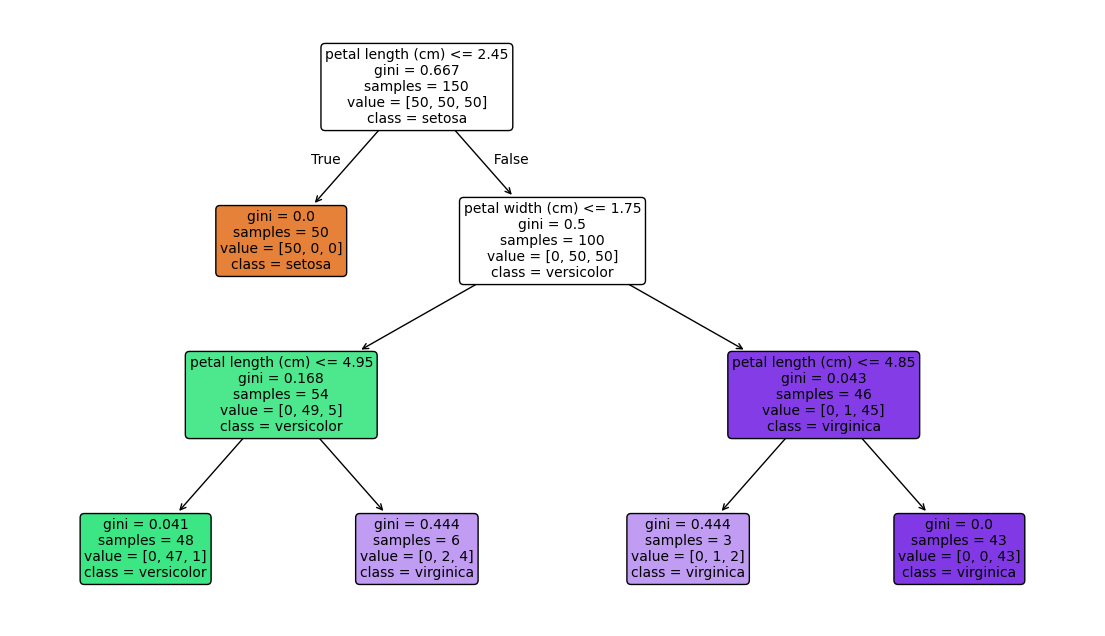

In [21]:
from sklearn.tree import plot_tree

plt.figure(figsize=(14,8))
plot_tree(
    tree_clf,
    feature_names=["petal length (cm)", "petal width (cm)"],
    class_names=iris.target_names,
    rounded=True,
    filled=True,
    fontsize=10
)
plt.show()

In [12]:
dot_data = export_graphviz(
    tree_clf,
    out_file=None,
    feature_names=["petal length (cm)", "petal width (cm)"],
    class_names=iris.target_names,
    rounded=True,
    filled=True
)

graph = graphviz.Source(dot_data)
graph.format = "png"
graph.view()

'Source.gv.png'

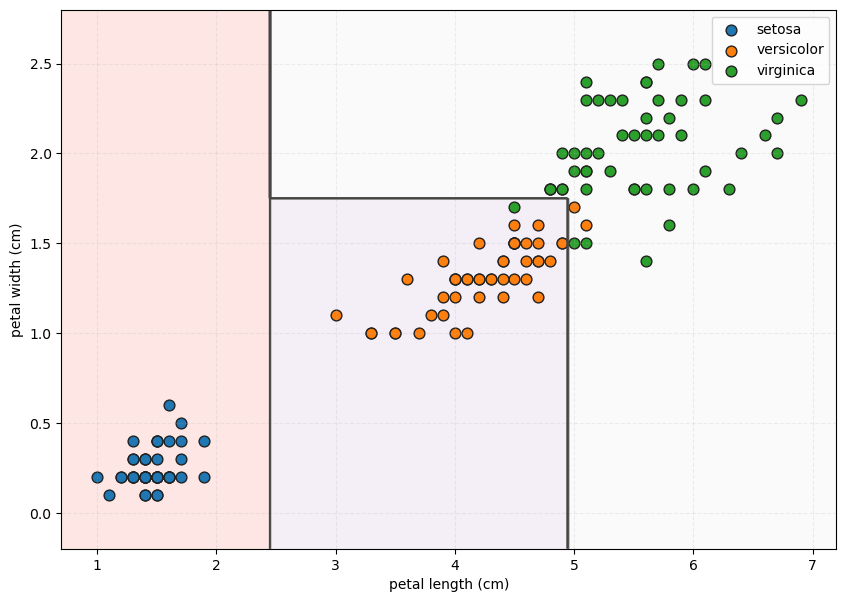

In [19]:
def plot_decision_boundary(clf, X, y):
    plt.figure(figsize=(10,7))
    x0_min, x0_max = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
    x1_min, x1_max = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3
    xx0, xx1 = np.meshgrid(np.linspace(x0_min, x0_max, 300),
                           np.linspace(x1_min, x1_max, 300))
    grid = np.c_[xx0.ravel(), xx1.ravel()]
    
    pred = clf.predict(grid)
    pred = pred.reshape(xx0.shape)

    plt.contourf(xx0, xx1, pred, alpha=0.32, cmap="Pastel1")
    plt.contour(xx0, xx1, pred, colors="#444444", linewidths=0.75)

    # 循环绘制每一类样本
    class_names = iris.target_names
    for idx, name in enumerate(class_names):
        mask = (y == idx)
        plt.scatter(X[mask,0], X[mask,1], s=60, edgecolors="#222222", label=name)

    plt.xlabel("petal length (cm)")
    plt.ylabel("petal width (cm)")
    plt.legend(fontsize=10)
    plt.grid(alpha=0.2, linestyle="--")
    plt.show()

plot_decision_boundary(tree_clf, X_iris, y_iris)

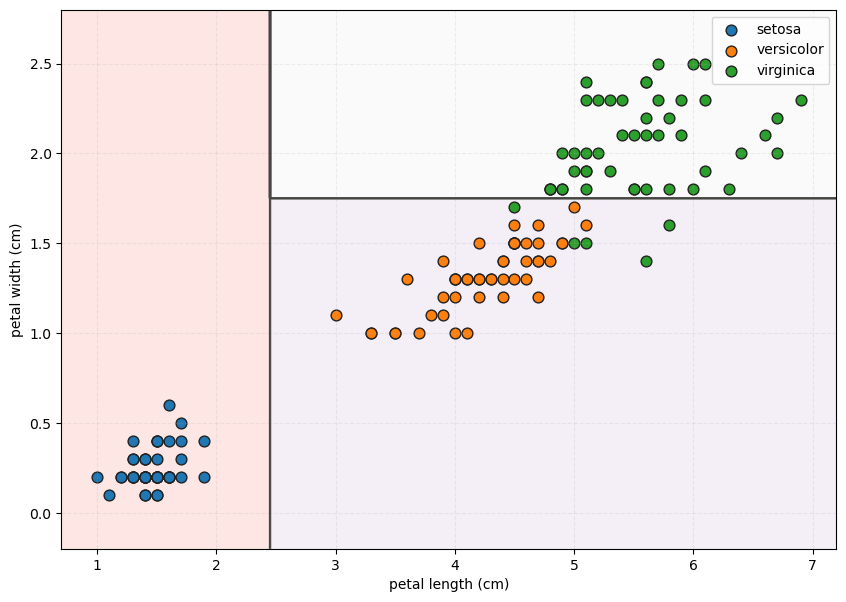

In [24]:
tree_clf_back = DecisionTreeClassifier(ccp_alpha=0.03, random_state=42)
tree_clf_back.fit(X_iris, y_iris)
plot_decision_boundary(tree_clf_back, X_iris, y_iris)

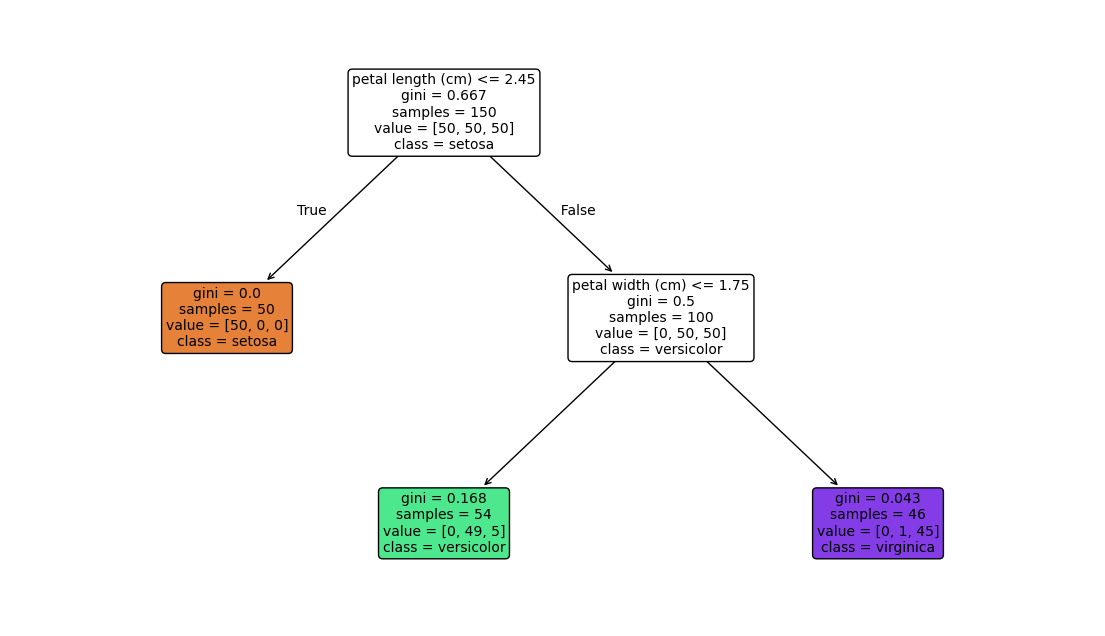

In [25]:
from sklearn.tree import plot_tree

plt.figure(figsize=(14,8))
plot_tree(
    tree_clf_back,
    feature_names=["petal length (cm)", "petal width (cm)"],
    class_names=iris.target_names,
    rounded=True,
    filled=True,
    fontsize=10
)
plt.show()